# AssureX Claim Engine — Multi-Model Training & Comparison

This notebook trains and compares four suitable classifiers: Logistic Regression, Random Forest, Extra Trees, and XGBoost. Selection is based on validation macro-F1, while 5-fold cross-validation is reported from the training split.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

from pathlib import Path
import pandas as pd
import numpy as np

DATA_NAME = "assurex_nigeria_warranty_claims_v2.csv"
CANDIDATES = [
    Path('/mnt/data') / DATA_NAME,
    Path(DATA_NAME),
    Path('../data') / DATA_NAME,
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Place {DATA_NAME} beside the notebook or in ../data/")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")

def engineer_features(frame):
    frame = frame.copy()
    for col in ['manufacture_date', 'purchase_date', 'fault_date', 'claim_date']:
        frame[col] = pd.to_datetime(frame[col], errors='coerce')
    frame['manufacture_to_purchase_days'] = (frame['purchase_date'] - frame['manufacture_date']).dt.days
    frame['purchase_to_fault_days'] = (frame['fault_date'] - frame['purchase_date']).dt.days
    frame['fault_to_claim_days'] = (frame['claim_date'] - frame['fault_date']).dt.days
    frame['claim_month'] = frame['claim_date'].dt.month
    return frame

# Keep business-rule outputs independent of the ML classifier.
# This avoids letting the Python model merely learn the final rule-engine result.
EXCLUDED_COLUMNS = {
    'claim_id', 'provenance_ref', 'split', 'claim_class',
    'manufacture_date', 'purchase_date', 'fault_date', 'claim_date', 'warranty_expiry_date',
    'fault_description', 'claim_narrative',
    'warranty_status', 'official_channel_status', 'fault_coverage_status',
    'serial_match_status', 'proof_of_purchase_status', 'duplicate_claim_indicator',
    'contradiction_flag', 'unauthorized_repair_flag', 'tamper_flag',
    'reported_within_return_window', 'statutory_3_month_window'
}

df_model = engineer_features(df)
FEATURE_COLUMNS = [c for c in df_model.columns if c not in EXCLUDED_COLUMNS]
X = df_model[FEATURE_COLUMNS]
y = df_model['claim_class']


Loaded: /mnt/data/assurex_nigeria_warranty_claims_v2.csv
Shape: (2400, 57)


In [2]:
train_mask = df_model['split'].eq('train')
val_mask = df_model['split'].eq('validation')
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

label_encoder = LabelEncoder().fit(y_train)
print('Classes:', list(label_encoder.classes_))

Classes: ['Likely Invalid', 'Likely Valid', 'Manual Review Required']


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=500, min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=350, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        objective='multi:softprob', eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
}
models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                        n_estimators=500, n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(class_weight='balanced', min_samples_leaf=2,
                      n_estimators=500, n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5

## Train, cross-validate, and score on validation set

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])

    if name == 'XGBoost':
        y_train_fit = label_encoder.transform(y_train)
        cv_result = cross_validate(
            pipe, X_train, y_train_fit, cv=cv,
            scoring={'accuracy':'accuracy', 'macro_f1':'f1_macro'}, n_jobs=1
        )
        pipe.fit(X_train, y_train_fit)
        val_pred = label_encoder.inverse_transform(pipe.predict(X_val).astype(int))
    else:
        cv_result = cross_validate(
            pipe, X_train, y_train, cv=cv,
            scoring={'accuracy':'accuracy', 'macro_f1':'f1_macro'}, n_jobs=1
        )
        pipe.fit(X_train, y_train)
        val_pred = pipe.predict(X_val)

    fitted_models[name] = pipe
    rows.append({
        'model': name,
        'cv_accuracy_mean': cv_result['test_accuracy'].mean(),
        'cv_accuracy_std': cv_result['test_accuracy'].std(),
        'cv_macro_f1_mean': cv_result['test_macro_f1'].mean(),
        'cv_macro_f1_std': cv_result['test_macro_f1'].std(),
        'validation_accuracy': accuracy_score(y_val, val_pred),
        'validation_macro_f1': f1_score(y_val, val_pred, average='macro')
    })

comparison = pd.DataFrame(rows).sort_values('validation_macro_f1', ascending=False).reset_index(drop=True)
display(comparison.round(4))

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,validation_accuracy,validation_macro_f1
0,XGBoost,0.9250,0.0155,0.9244,0.0160,0.9472,0.9468
1,Random Forest,0.9048,0.0202,0.9043,0.0206,0.9194,0.9192
2,Extra Trees,0.8679,0.0234,0.8678,0.0242,0.9000,0.8990
3,Logistic Regression,0.8470,0.0199,0.8465,0.0203,0.8806,0.8813


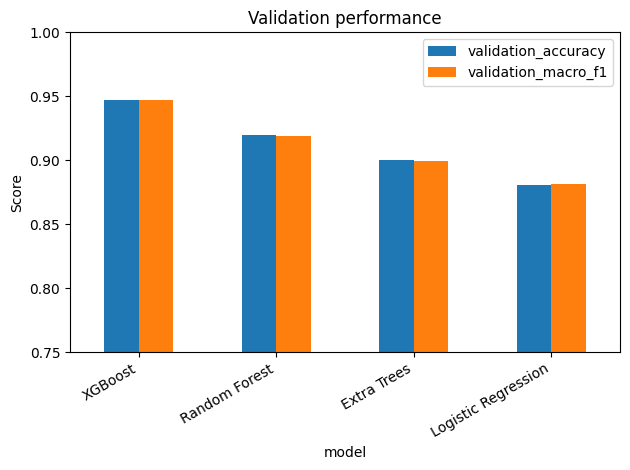

In [5]:
ax = comparison.set_index('model')[['validation_accuracy','validation_macro_f1']].plot(kind='bar', ylim=(0.75, 1.0), title='Validation performance')
ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [6]:
best_model_name = comparison.loc[0, 'model']
print('Selected model:', best_model_name)
print('Selection criterion: highest validation macro-F1')

Selected model: XGBoost
Selection criterion: highest validation macro-F1


## Interpretation

The model with the strongest validation macro-F1 is carried into the final notebook. The held-out test set is deliberately not used for model selection. This keeps model comparison defensible and consistent with the SRS requirement for unseen-test evaluation.